In [1]:
import os

print(os.getcwd())

c:\Users\leeri\Documents\AML\notebooks


In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/PS_20174392719_1491204439457_log.csv")

print(df.shape)
df.head()

(1048575, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# Dataset Characteristics

1. Shape
2. Statistical Info
3. Value Counts
4. Describe

In [3]:
print(df.shape)

(1048575, 11)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  str    
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  str    
 4   oldbalanceOrg   1048575 non-null  float64
 5   newbalanceOrig  1048575 non-null  float64
 6   nameDest        1048575 non-null  str    
 7   oldbalanceDest  1048575 non-null  float64
 8   newbalanceDest  1048575 non-null  float64
 9   isFraud         1048575 non-null  int64  
 10  isFlaggedFraud  1048575 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 88.0 MB


In [5]:
df['isFraud'].value_counts()

isFraud
0    1047433
1       1142
Name: count, dtype: int64

In [6]:
df['isFraud'].value_counts(normalize=True)*100

isFraud
0    99.89109
1     0.10891
Name: proportion, dtype: float64

In [7]:
df['type'].value_counts()

type
CASH_OUT    373641
PAYMENT     353873
CASH_IN     227130
TRANSFER     86753
DEBIT         7178
Name: count, dtype: int64

In [8]:
pd.crosstab(
    df['type'],
    df['isFraud']
)

isFraud,0,1
type,,
CASH_IN,227130,0
CASH_OUT,373063,578
DEBIT,7178,0
PAYMENT,353873,0
TRANSFER,86189,564


In [9]:
df['amount'].describe()

count    1.048575e+06
mean     1.586670e+05
std      2.649409e+05
min      1.000000e-01
25%      1.214907e+04
50%      7.634333e+04
75%      2.137619e+05
max      1.000000e+07
Name: amount, dtype: float64

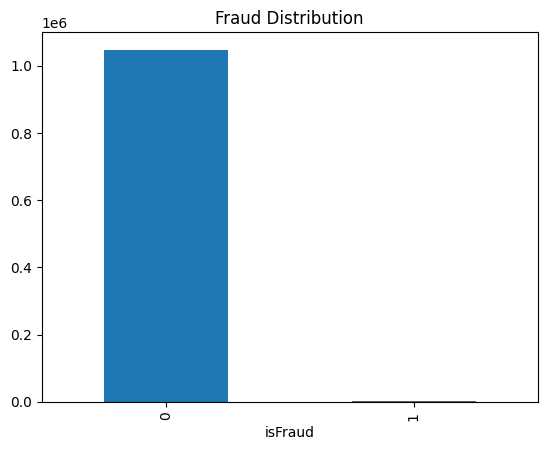

In [10]:
import matplotlib.pyplot as plt

df["isFraud"].value_counts().plot(
    kind="bar"
)

plt.title("Fraud Distribution")
plt.show()

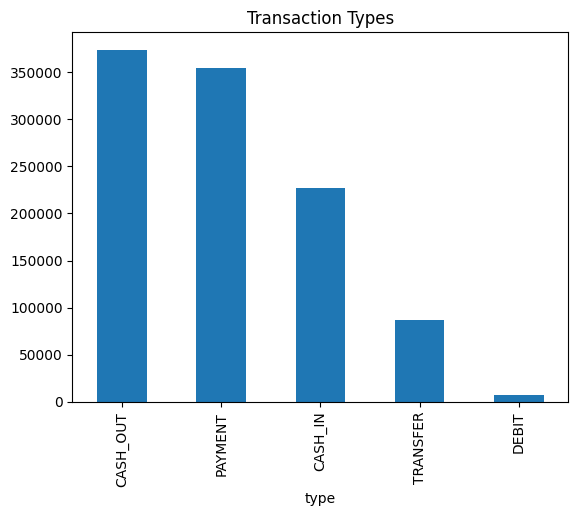

In [11]:
df["type"].value_counts().plot(
    kind="bar"
)

plt.title("Transaction Types")
plt.show()

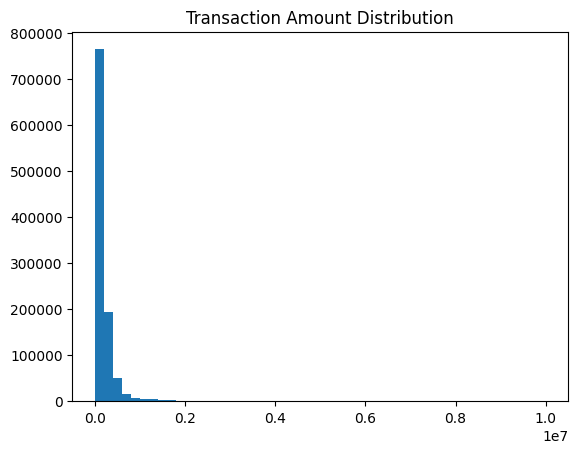

In [12]:
plt.hist(
    df["amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.show()

In [13]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1048570,95,CASH_OUT,132557.35,C1179511630,479803.00,347245.65,C435674507,484329.37,616886.72,0,0
1048571,95,PAYMENT,9917.36,C1956161225,90545.00,80627.64,M668364942,0.00,0.00,0,0
1048572,95,PAYMENT,14140.05,C2037964975,20545.00,6404.95,M1355182933,0.00,0.00,0,0
1048573,95,PAYMENT,10020.05,C1633237354,90605.00,80584.95,M1964992463,0.00,0.00,0,0
1048574,95,PAYMENT,11450.03,C1264356443,80584.95,69134.92,M677577406,0.00,0.00,0,0


In [14]:
df["step"].max()

np.int64(95)

In [15]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    1048575
Name: count, dtype: int64

In [16]:
pd.crosstab(df["type"], df["isFraud"], normalize="index") * 100

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.845306,0.154694
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.349878,0.650122


In [17]:
customer_profile = (
    df.groupby("nameOrig")
      .agg(
          TotalTransactions=("amount", "count"),
          TotalVolume=("amount", "sum"),
          AvgTransactionAmount=("amount", "mean"),
          FraudCount=("isFraud", "sum")
      )
      .reset_index()
)

customer_profile.head()

,nameOrig,TotalTransactions,TotalVolume,AvgTransactionAmount,FraudCount
0,C1000001725,1,8424.74,8424.74,0
1,C1000004530,1,93865.13,93865.13,0
2,C1000008582,1,315626.96,315626.96,0
3,C1000009135,1,3849.38,3849.38,0
4,C1000012640,1,367527.28,367527.28,0


In [18]:
customer_profile.shape

(1048317, 5)

In [19]:
customer_profile.head(20)

,nameOrig,TotalTransactions,TotalVolume,AvgTransactionAmount,FraudCount
0,C1000001725,1,8424.74,8424.74,0
1,C1000004530,1,93865.13,93865.13,0
2,C1000008582,1,315626.96,315626.96,0
3,C1000009135,1,3849.38,3849.38,0
4,C1000012640,1,367527.28,367527.28,0
5,C1000018663,1,12454.86,12454.86,0
6,C1000022742,1,2368.68,2368.68,0
7,C1000024318,1,71260.70,71260.70,0
8,C1000025173,1,1634.55,1634.55,0
9,C1000025399,1,66455.81,66455.81,0


In [20]:
customer_profile.describe()

,TotalTransactions,TotalVolume,AvgTransactionAmount,FraudCount
count,1.048317e+06,1.048317e+06,1.048317e+06,1.048317e+06
mean,1.000246e+00,1.587060e+05,1.586665e+05,1.089365e-03
std,1.568593e-02,2.649919e+05,2.649405e+05,3.298757e-02
min,1.000000e+00,1.000000e-01,1.000000e-01,0.000000e+00
25%,1.000000e+00,1.215138e+04,1.215026e+04,0.000000e+00
50%,1.000000e+00,7.637381e+04,7.635331e+04,0.000000e+00
75%,1.000000e+00,2.137959e+05,2.137511e+05,0.000000e+00
max,2.000000e+00,1.000000e+07,1.000000e+07,1.000000e+00


In [21]:
customer_profile.sort_values(
    by="TotalVolume",
    ascending=False
).head(10)

,nameOrig,TotalTransactions,TotalVolume,AvgTransactionAmount,FraudCount
953130,C824646662,1,10000000.0,10000000.0,1
792892,C53057884,1,10000000.0,10000000.0,1
42882,C1079335762,1,10000000.0,10000000.0,1
796974,C538142346,1,10000000.0,10000000.0,1
935728,C792651637,1,10000000.0,10000000.0,1
695627,C351297720,1,10000000.0,10000000.0,1
456896,C1843531771,1,10000000.0,10000000.0,1
569072,C2050703310,1,10000000.0,10000000.0,1
663276,C29118015,1,10000000.0,10000000.0,1
237571,C1438388258,1,10000000.0,10000000.0,1


In [22]:
customer_profile.sort_values(
    by="FraudCount",
    ascending=False
).head(10)

,nameOrig,TotalTransactions,TotalVolume,AvgTransactionAmount,FraudCount
46433,C1085892947,1,604933.67,604933.67,1
174193,C1322100754,1,454511.73,454511.73,1
151103,C1279213624,1,122235.11,122235.11,1
472190,C1872047468,1,235238.66,235238.66,1
17524,C1032400193,1,21367.00,21367.00,1
193989,C135832352,1,6188514.81,6188514.81,1
275076,C1507825825,1,18887.00,18887.00,1
9162,C1016889565,1,456745.18,456745.18,1
14209,C1026280121,1,1078013.76,1078013.76,1
6890,C1012580160,1,128473.62,128473.62,1


In [23]:
customer_profile.shape

(1048317, 5)

In [24]:
customer_profile["TotalVolume"].describe()

count    1.048317e+06
mean     1.587060e+05
std      2.649919e+05
min      1.000000e-01
25%      1.215138e+04
50%      7.637381e+04
75%      2.137959e+05
max      1.000000e+07
Name: TotalVolume, dtype: float64

In [25]:
customer_profile["TotalVolume"].describe()

count    1.048317e+06
mean     1.587060e+05
std      2.649919e+05
min      1.000000e-01
25%      1.215138e+04
50%      7.637381e+04
75%      2.137959e+05
max      1.000000e+07
Name: TotalVolume, dtype: float64

In [26]:
customer_profile["TotalTransactions"].describe()

count    1.048317e+06
mean     1.000246e+00
std      1.568593e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      2.000000e+00
Name: TotalTransactions, dtype: float64

In [27]:
customer_profile.columns

Index(['nameOrig', 'TotalTransactions', 'TotalVolume', 'AvgTransactionAmount',
       'FraudCount'],
      dtype='str')

In [28]:
customer_profile["RiskScore"] = 0

In [29]:
customer_profile.loc[
    customer_profile["TotalVolume"] > 500000,
    "RiskScore"
] += 25

customer_profile.loc[
    customer_profile["TotalTransactions"] > 10,
    "RiskScore"
] += 20

customer_profile.loc[
    customer_profile["FraudCount"] > 0,
    "RiskScore"
] += 50

In [30]:
def categorize(score):
    if score >= 70:
        return "Critical"
    elif score >= 40:
        return "High"
    elif score >= 20:
        return "Medium"
    else:
        return "Low"

In [31]:
customer_profile["RiskLevel"] = (
    customer_profile["RiskScore"]
    .apply(categorize)
)

In [32]:
customer_profile[["RiskScore", "RiskLevel"]].head()

,RiskScore,RiskLevel
0,0,Low
1,0,Low
2,0,Low
3,0,Low
4,0,Low


In [33]:
customer_profile["RiskLevel"].value_counts()

RiskLevel
Low         990998
Medium       56177
High           672
Critical       470
Name: count, dtype: int64

In [34]:
customer_profile.columns.tolist()

['nameOrig',
 'TotalTransactions',
 'TotalVolume',
 'AvgTransactionAmount',
 'FraudCount',
 'RiskScore',
 'RiskLevel']

In [35]:
customer_profile["VolumePerTransaction"] = (
    customer_profile["TotalVolume"] /
    customer_profile["TotalTransactions"]
)

In [36]:
customer_profile["TotalVolume"].quantile(
    [0.5, 0.75, 0.9, 0.95, 0.99]
)

0.50      76373.810
0.75     213795.870
0.90     373143.044
0.95     519627.588
0.99    1309495.170
Name: TotalVolume, dtype: float64

In [37]:
customer_profile["RiskLevel"].value_counts()

RiskLevel
Low         990998
Medium       56177
High           672
Critical       470
Name: count, dtype: int64

In [38]:
customer_profile.shape

(1048317, 8)

In [39]:
customer_profile.rename(
    columns={"nameOrig": "CustomerID"},
    inplace=True
)

In [40]:
from sqlalchemy import create_engine

server = "localhost"
database = "aml_data"

connection_string = (
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

engine = create_engine(connection_string)


customer_profile.to_sql(
    "CustomerRisk",
    engine,
    if_exists="replace",
    index=False
)

55

In [41]:
with engine.connect() as conn:
    print("Connected Successfully")

Connected Successfully


In [42]:
customer_profile.columns

Index(['CustomerID', 'TotalTransactions', 'TotalVolume',
       'AvgTransactionAmount', 'FraudCount', 'RiskScore', 'RiskLevel',
       'VolumePerTransaction'],
      dtype='str')

In [43]:
alert_queue = customer_profile[
    customer_profile["RiskLevel"].isin(
        ["High", "Critical"]
    )
].copy()

In [44]:
alert_queue.shape

(1142, 8)

In [45]:
alert_queue["AlertPriority"] = (
    alert_queue["RiskScore"]
      .rank(
          method="dense",
          ascending=False
      )
)

In [46]:
alert_queue.to_sql(
    "AlertQueue",
    engine,
    if_exists="replace",
    index=False
)

210

In [47]:
transaction_summary = (
    df.groupby("type")
      .agg(
          TotalTransactions=("amount", "count"),
          TotalAmount=("amount", "sum"),
          AverageAmount=("amount", "mean"),
          FraudTransactions=("isFraud", "sum")
      )
      .reset_index()
)

In [48]:
transaction_summary["FraudRate"] = (
    transaction_summary["FraudTransactions"]
    / transaction_summary["TotalTransactions"]
) * 100

In [49]:
fraud_exposure = (
    df[df["isFraud"] == 1]
    .groupby("type")["amount"]
    .sum()
)

In [50]:
transaction_summary["FraudExposure"] = (
    transaction_summary["type"]
    .map(fraud_exposure)
    .fillna(0)
)

In [51]:
transaction_summary

,type,TotalTransactions,TotalAmount,AverageAmount,FraudTransactions,FraudRate,FraudExposure
0,CASH_IN,227130,3.859476e+10,169923.648522,0,0.000000,0.000000e+00
1,CASH_OUT,373641,6.876474e+10,184039.592505,578,0.154694,6.803839e+08
2,DEBIT,7178,4.219599e+07,5878.516989,0,0.000000,0.000000e+00
3,PAYMENT,353873,3.936097e+09,11122.907151,0,0.000000,0.000000e+00
4,TRANSFER,86753,5.503644e+10,634403.832422,564,0.650122,6.815984e+08


In [52]:
def transaction_risk(rate):
    if rate >= 0.5:
        return "Critical"
    elif rate >= 0.1:
        return "High"
    elif rate > 0:
        return "Medium"
    return "Low"

In [59]:
transaction_summary["RiskCategory"] = (
    transaction_summary["FraudRate"]
    .apply(transaction_risk)
)

In [54]:
transaction_summary

,type,TotalTransactions,TotalAmount,AverageAmount,FraudTransactions,FraudRate,FraudExposure,RiskCategory
0,CASH_IN,227130,3.859476e+10,169923.648522,0,0.000000,0.000000e+00,Low
1,CASH_OUT,373641,6.876474e+10,184039.592505,578,0.154694,6.803839e+08,High
2,DEBIT,7178,4.219599e+07,5878.516989,0,0.000000,0.000000e+00,Low
3,PAYMENT,353873,3.936097e+09,11122.907151,0,0.000000,0.000000e+00,Low
4,TRANSFER,86753,5.503644e+10,634403.832422,564,0.650122,6.815984e+08,Critical


In [60]:
transaction_summary.rename(
    columns={"type": "TransactionType"},
    inplace=True
)

In [61]:
transaction_summary.to_sql(
    "TransactionSummary",
    engine,
    if_exists="replace",
    index=False
)

5

In [62]:
transaction_summary.shape

(5, 8)

In [65]:
high_risk_transactions = df[
    (
        (df["isFraud"] == 1)
        |
        (
            (df["amount"] > 500000)
            &
            (
                df["type"].isin(
                    ["TRANSFER", "CASH_OUT"]
                )
            )
        )
    )
].copy()

In [66]:
high_risk_transactions["TransactionRiskScore"] = 0

In [67]:
high_risk_transactions.loc[
    high_risk_transactions["isFraud"] == 1,
    "TransactionRiskScore"
] += 70

In [68]:
high_risk_transactions.loc[
    high_risk_transactions["amount"] > 500000,
    "TransactionRiskScore"
] += 20

In [69]:
high_risk_transactions.loc[
    high_risk_transactions["type"] == "TRANSFER",
    "TransactionRiskScore"
] += 15

In [70]:
def classify_transaction(score):
    if score >= 80:
        return "Critical"
    elif score >= 50:
        return "High"
    return "Medium"

In [71]:
high_risk_transactions["TransactionRiskLevel"] = (
    high_risk_transactions["TransactionRiskScore"]
    .apply(classify_transaction)
)

In [72]:
high_risk_transactions.shape

(52742, 13)

In [73]:
high_risk_transactions[
    [
        "type",
        "amount",
        "isFraud",
        "TransactionRiskScore",
        "TransactionRiskLevel"
    ]
].head()

,type,amount,isFraud,TransactionRiskScore,TransactionRiskLevel
2,TRANSFER,181.00,1,85,Critical
3,CASH_OUT,181.00,1,70,High
85,TRANSFER,1505626.01,0,35,Medium
86,TRANSFER,554026.99,0,35,Medium
88,TRANSFER,761507.39,0,35,Medium


In [75]:
high_risk_transactions_sql = high_risk_transactions[
    [
        "step",
        "type",
        "amount",
        "nameOrig",
        "nameDest",
        "isFraud",
        "TransactionRiskScore",
        "TransactionRiskLevel"
    ]
]

In [76]:
high_risk_transactions_sql.columns

Index(['step', 'type', 'amount', 'nameOrig', 'nameDest', 'isFraud',
       'TransactionRiskScore', 'TransactionRiskLevel'],
      dtype='str')

In [77]:
high_risk_transactions_sql.to_sql(
    name="HighRiskTransactions",
    con=engine,
    if_exists="append",
    index=False
)

print("Inserted:", len(high_risk_transactions_sql))

Inserted: 52742


In [78]:
daily_metrics = (
    df.groupby("step")
      .agg(
          TotalTransactions=("amount", "count"),
          TotalAmount=("amount", "sum"),
          FraudTransactions=("isFraud", "sum")
      )
      .reset_index()
)

In [79]:
daily_metrics["FraudRate"] = (
    daily_metrics["FraudTransactions"]
    / daily_metrics["TotalTransactions"]
) * 100

In [80]:
fraud_exposure_daily = (
    df[df["isFraud"] == 1]
    .groupby("step")["amount"]
    .sum()
)

In [81]:
daily_metrics["FraudExposure"] = (
    daily_metrics["step"]
    .map(fraud_exposure_daily)
    .fillna(0)
)

In [82]:
daily_metrics["AlertFlag"] = (
    daily_metrics["FraudTransactions"] > 5
).astype(int)

In [83]:
def trend_risk(rate):
    if rate >= 1:
        return "Critical"
    elif rate >= 0.5:
        return "High"
    elif rate > 0:
        return "Medium"
    return "Low"

In [84]:
daily_metrics["TrendRiskLevel"] = (
    daily_metrics["FraudRate"]
    .apply(trend_risk)
)

In [85]:
daily_metrics.head()

,step,TotalTransactions,TotalAmount,FraudTransactions,FraudRate,FraudExposure,AlertFlag,TrendRiskLevel
0,1,2708,2.854292e+08,16,0.590842,3740247.01,1,High
1,2,1014,8.592160e+07,8,0.788955,4186592.48,1,High
2,3,552,4.329388e+07,4,0.724638,66832.74,0,High
3,4,565,7.291003e+07,10,1.769912,26400274.90,1,Critical
4,5,665,4.554809e+07,6,0.902256,381841.54,1,High


In [86]:
daily_metrics.describe()

,step,TotalTransactions,TotalAmount,FraudTransactions,FraudRate,FraudExposure,AlertFlag
count,95.000000,95.000000,9.500000e+01,95.000000,95.000000,9.500000e+01,95.000000
mean,48.000000,11037.631579,1.751308e+09,12.021053,50.872459,1.433666e+07,0.905263
std,27.568098,16488.396350,2.689236e+09,5.299496,49.950688,1.390804e+07,0.294405
min,1.000000,4.000000,9.752009e+05,2.000000,0.009846,6.683274e+04,0.000000
25%,24.500000,10.000000,1.026425e+07,8.000000,0.051374,3.868529e+06,1.000000
50%,48.000000,24.000000,4.352599e+07,12.000000,100.000000,1.051222e+07,1.000000
75%,71.500000,22244.000000,3.608633e+09,16.000000,100.000000,2.006222e+07,1.000000
max,95.000000,51352.000000,7.255072e+09,24.000000,100.000000,6.299009e+07,1.000000


In [87]:
daily_metrics.to_sql(
    name="DailyTransactionMetrics",
    con=engine,
    if_exists="append",
    index=False
)

95